**Using the LFW in the wirld dataset to builda siamese network trained with triplet loss**

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import transforms
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from typing import List, Dict

In [2]:
# define the root path with the images
root_path = "../../data/faces"

In [3]:
# read the labels description file
label_desc = pd.read_csv(f"{root_path}/Dataset.csv")
label_desc.head(4)

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish


In [4]:
# going to have to generate numeric labels for the images
# above file maps raw image name to a unique name...
# create list of unique names and index that with a name to get the corresponding numeric label for an image
label_desc['label'].unique().tolist().index('Robert Downey Jr')

0

In [5]:
# generate all the labels and then store them in a list
labels = label_desc['label'].unique().tolist()

In [6]:
# can't keep on using the dataframe so going to convert it into a dictionary that maps image name to a unique label
label_dict = {k:v for k,v in zip(label_desc['id'].values, label_desc['label'].values)}

Visualise some of the images in the dataset

(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

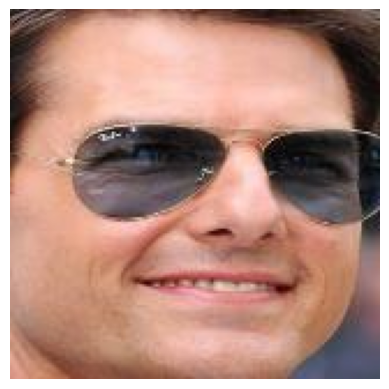

In [13]:
image = Image.open(f"{root_path}/Faces/Faces/Tom Cruise_44.jpg").convert("RGB")
image = np.array(image)
plt.imshow(image)
plt.axis("off")

The dataset isn't internally split into train, val, and test folds..so going to have to create those..

In [20]:
training_identities = labels[:21]
val_identities = labels[21:26]
test_identities = labels[26:]

In [21]:
len(training_identities), len(val_identities), len(test_identities)

(21, 5, 5)

In [24]:
# need to get the corresponding raw images from the label_dict dictionary
train_label_dict = {
    k:v
    for k,v in label_dict.items()
    if v in training_identities
}

val_label_dict = {
    k:v
    for k,v in label_dict.items()
    if v in val_identities
}

test_label_dict = {
    k:v
    for k,v in label_dict.items()
    if v in test_identities
}

In [33]:
train_files = list(train_label_dict.keys())
val_files = list(val_label_dict.keys())
test_files = list(test_label_dict.keys())

In [34]:
print(f"Training Instances: {len(train_files)} | Val Instances: {len(val_files)} | Test Instances: {len(test_files)}")

Training Instances: 1778 | Val Instances: 417 | Test Instances: 367


Build out the dataset

In [35]:
np.random.choice?

Signature: np.random.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. versionadded:: 1.7.0

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a


In [50]:
class FacesDataset(Dataset):
    def __init__(self, root_dir:str, files:List[str], labels:List[str], label_dict:Dict[str,str], examples_per_anchor: int =3, transforms=None):
        super().__init__()
        self.root_dir = root_dir + "/Faces/Faces"
        self.transforms = transforms
        self.examples_per_anchor = examples_per_anchor

        # building the numeric labels
        self.numeric_labels = np.array(list(map(lambda x: labels.index(x), labels)))

        # for each image in files, need to build/generate a label for it from the labels list so as to have a labels list of numeric type that is as long as the files list
        self.numeric_labels_all = np.array(list(map(lambda x: labels.index(label_dict.get(x)), files)))

        self.files = files

        self.triplets = self.build_triplets()

    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, index):
        if self.transforms:
            if self.triplets[index].ndim == 5:
                anchor, pos, neg = self.triplets[index][:, 0], self.triplets[index][:, 1], self.triplets[index][:, 2]
                anchor, pos, neg = self.transforms(torch.tensor(anchor)), self.transforms(torch.tensor(pos)), self.transforms(torch.tensor(neg))
                triplet = torch.stack((anchor, pos, neg), dim=1)
                return triplet
            elif self.triplets[index].ndim == 4:
                anchor, pos, neg = self.triplets[index][0], self.triplets[index][1], self.triplets[index][2]
                anchor, pos, neg = self.transforms(torch.tensor(anchor)), self.transforms(torch.tensor(pos)), self.transforms(torch.tensor(neg))
                triplet = torch.stack((anchor, pos, neg), dim=0)
                return triplet 
        return self.triplets[index]
    
    def build_triplets(self):
        # idea behind triplets is that for each image - as an anchor, get  the positive and negative examples
        # for each identitiy aim for at least examples_per_anchor number of examples
        triplets = []

        # for each label in the distinct numeric labels, get the img_indices that correspond to that particular label
        similar_img_indices = [np.where(self.numeric_labels_all==label)[0] for label in self.numeric_labels]

        # dissimilar image indices - the opposite of the above
        dissimilar_img_indices = [np.where(self.numeric_labels_all != label)[0] for label in self.numeric_labels]

        np.random.seed(42)

        to_tensor = transforms.ToTensor()

        for i, img_path in enumerate(self.files):
            anchor = Image.open(f"{self.root_dir}/{img_path}")
            anchor_label = self.numeric_labels_all[i]
            anchor = to_tensor(anchor)
            # for each example , like this anchor, generate 3 triplets examples
            # for the similar image indices, filter out the already chosen 
            similar_img_indices_temp = similar_img_indices[anchor_label]
            similar_img_indices_temp = similar_img_indices_temp[similar_img_indices_temp != i]

            # randomly choose 3 similar images
            similar_idx = np.random.choice(similar_img_indices_temp, self.examples_per_anchor, replace=False)

            # randomly choose 3 dissimilar images too
            dissimilar_idx = np.random.choice(dissimilar_img_indices[anchor_label], self.examples_per_anchor, replace=False)

            for idx1,idx2 in zip(similar_idx,dissimilar_idx):
                sim_img = Image.open(f"{self.root_dir}/{self.files[idx1]}")
                sim_img = to_tensor(sim_img)

                dissim_img = Image.open(f"{self.root_dir}/{self.files[idx2]}")
                dissim_img = to_tensor(dissim_img)

                triplets.append((anchor, sim_img, dissim_img))

        return np.array(triplets)

In [39]:
triplets_dataset = FacesDataset(root_dir=root_path, files= train_files, labels=np.unique(list(train_label_dict.values())).tolist(), label_dict = train_label_dict)

In [40]:
np.random.seed(4122)
query_indices = np.random.choice(np.arange(len(train_files)), size=10)
triplets_examples = triplets_dataset[query_indices.tolist()]

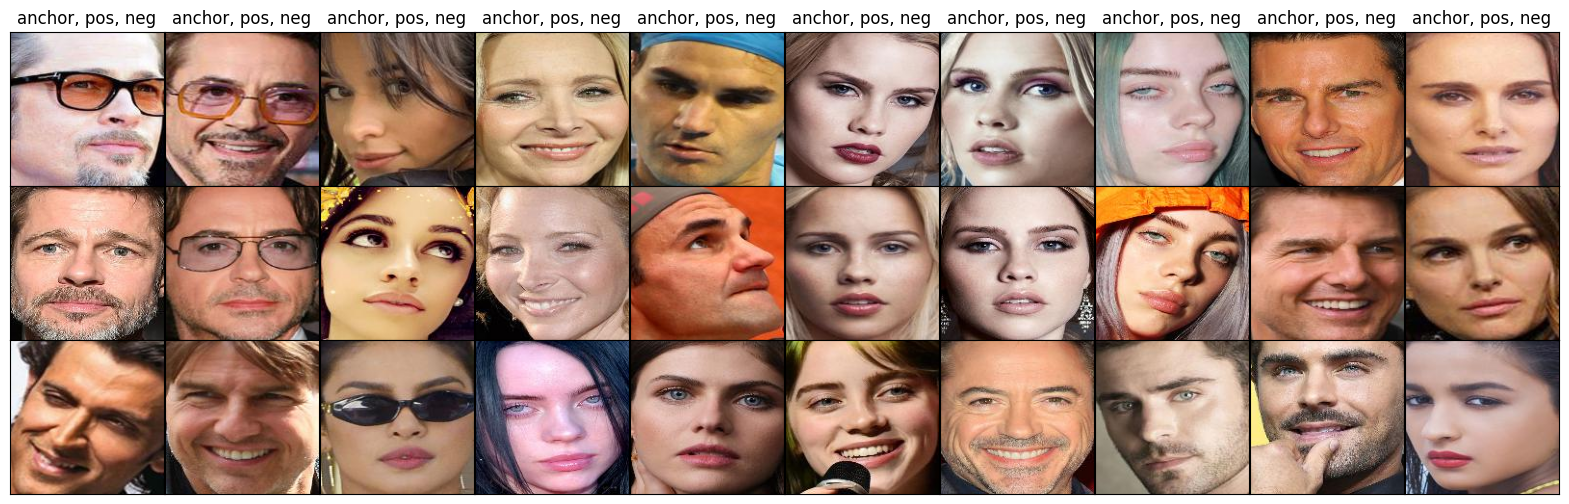

In [43]:
fig, ax = plt.subplots(3,10, figsize=(20,6))
fig.subplots_adjust(hspace=0, wspace=0)

for i in range(3):
    for j in range(10):
        ax[i,j].imshow(triplets_examples[j][i].transpose(1,2,0))
        if i == 0:
            ax[i,j].set_title("anchor, pos, neg")
        ax[i,j].set_xticks([]); ax[i,j].set_yticks([]);

Data transformations:

In [68]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(160),
    transforms.RandomHorizontalFlip()
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(160),
])

In [69]:
triplets_train = FacesDataset(root_dir=root_path, files= train_files, labels=np.unique(list(train_label_dict.values())).tolist(), label_dict = train_label_dict, transforms=train_transforms)

In [70]:
np.random.seed(585)
query_indices = np.random.choice(np.arange(len(train_files)), size=10)
triplets_examples = triplets_train[query_indices.tolist()]

Triplets with the transformations:

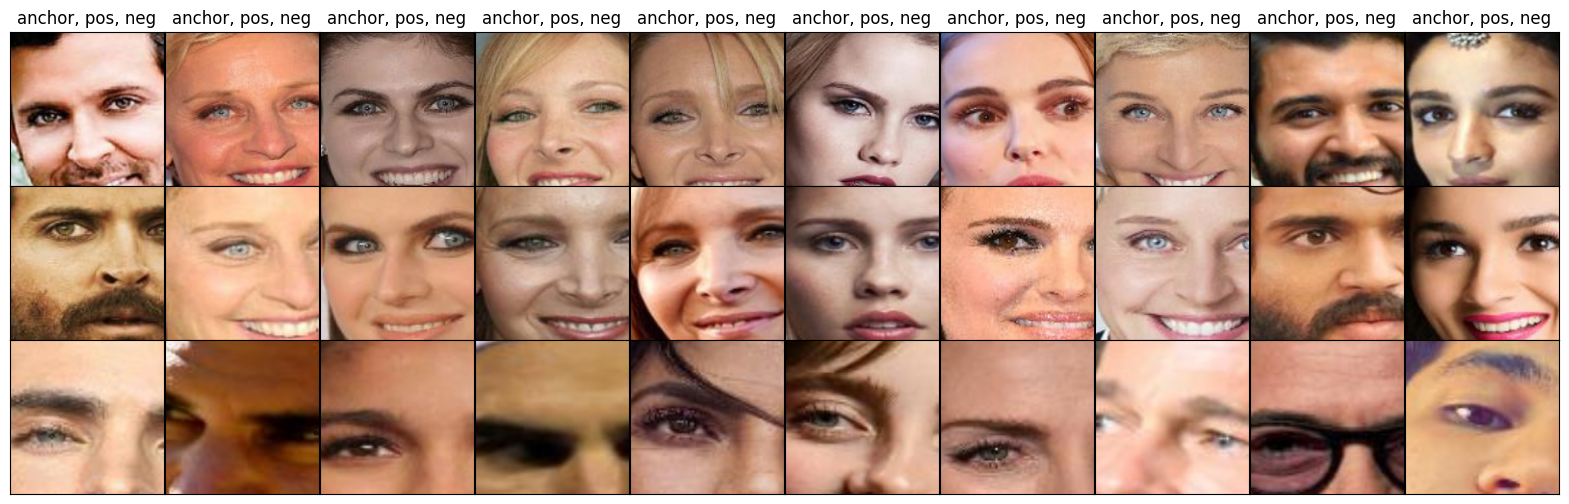

In [71]:
fig, ax = plt.subplots(3,10, figsize=(20,6))
fig.subplots_adjust(hspace=0, wspace=0)

for i in range(3):
    for j in range(10):
        ax[i,j].imshow(triplets_examples.clone().numpy()[j][i].transpose(1,2,0))
        if i == 0:
            ax[i,j].set_title("anchor, pos, neg")
        ax[i,j].set_xticks([]); ax[i,j].set_yticks([]);

In [72]:
triplets_val = FacesDataset(root_dir=root_path, files= val_files, labels=np.unique(list(val_label_dict.values())).tolist(), label_dict = val_label_dict, transforms=val_transforms)
triplets_test = FacesDataset(root_dir=root_path, files= test_files, labels=np.unique(list(test_label_dict.values())).tolist(), label_dict = test_label_dict)

In [73]:
len(triplets_train), len(triplets_val), len(triplets_test)

(5334, 1251, 1101)

**Dataloaders:**

In [74]:
triplets_train_dl = DataLoader(triplets_train, batch_size=64, shuffle=True)
triplets_val_dl = DataLoader(triplets_val, batch_size=64)
triplets_test_dl = DataLoader(triplets_test, batch_size=64)